# 34 - Sampling ω_dm,tot instead of ω_cdm

The accDM parent density is f_acc·ω_cdm, added on top of ω_cdm (`rho_acc_cdm` in `background.c`), so the total
cold dark matter before the transition, scaled to today as a⁻³, is

$$\omega_{\rm dm,tot} = \omega_{\rm cdm}\,(1 + f_{\rm acc}).$$

Today the parent is gone and the daughters carry its energy, so ω_dm,tot is also the present-day ω_cdm + ω_daughter,
up to the daughters' leftover kinetic energy (section 1b: 2.7% of the daughter density at 10¹¹ GeV, 0.2% at
10¹² GeV, below 10⁻⁵ from 10¹⁵ GeV up). Relative to the total this is 0.027·f_acc/(1 + f_acc) at 10¹¹ GeV,
below 10⁻⁴ for the f_acc the 10¹¹ chains allow.

`input.c` accepts `omega_dm_tot` in place of `omega_cdm`: CLASS sets ω_cdm = ω_dm,tot/(1 + f_acc) and nothing
downstream changes. The two parametrizations describe the same model:

| | inputs | ω_cdm | parent (before transition) ≈ daughter (today) |
|---|---|---|---|
| previous | ω_cdm, f_acc | input | f_acc·ω_cdm |
| new | ω_dm,tot, f_acc | ω_dm,tot/(1 + f_acc) | ω_dm,tot·f_acc/(1 + f_acc) |

f_acc keeps its meaning and its linear prior; only the second coordinate changes. A fraction f_acc/(1 + f_acc) of
the total is parent, 0 to 0.91 over f_acc ∈ [0, 10].

- **1** checks that CLASS gives identical output for the same model in both parametrizations, and what ω_dm,tot
  is today.
- **2** shows what the fixed-mass CONNECT chains measure: ω_dm,tot is pinned at every mass, ω_cdm is not.
- **3** shows why this matters for the emulator: the shape of the high-likelihood region and how many training
  points land on it.
- **4** shows the one real difference, the implied prior, and what it does to the f_acc posterior.

Chains: `chains/fixed_masses/connect/new`, 30% burn-in. Runtime about 2 min (section 1 runs CLASS).

In [1]:
import multiprocessing as mp
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from classy import Class

import figkit as fk

fk.use('quick')


def find_root(start=None):
    start = Path.cwd() if start is None else start
    for d in [start, *start.parents]:
        if (d/'chains'/'fixed_masses').is_dir():
            return d
    raise FileNotFoundError('no chains/fixed_masses above {}'.format(start))


def read_bestfit(path):
    with open(path) as fh:
        names = [s.strip() for s in fh.readline().lstrip('#').split(',')]
        values = [float(v) for v in fh.readline().split()]
    return dict(zip(names, values))


CHAINS = find_root()/'chains'/'fixed_masses'/'connect'/'new'
BURN_IN = 0.3


def is_mass(name):
    try:
        float(name)
        return True
    except ValueError:
        return False


def chain_dirs(min_log10m=-np.inf):
    """Fixed-mass chain folders (named by log10 m) that hold chain files, by mass."""
    dirs = [d for d in CHAINS.iterdir()
            if d.is_dir() and is_mass(d.name) and float(d.name) >= min_log10m and any(d.glob('*__*.txt'))]
    return sorted(dirs, key=lambda d: float(d.name))


def load_chain(directory):
    """Post-burn-in samples of one MontePython chain folder, with omega_dm_tot added."""
    names = [line.split()[0] for line in open(next(directory.glob('*_.paramnames')))]
    blocks = []
    for path in sorted(directory.glob('*__*.txt')):
        data = pd.read_csv(path, sep=r'\s+', header=None, comment='#').to_numpy()
        blocks.append(data[int(BURN_IN*len(data)):])
    data = np.vstack(blocks)
    out = {'weight': data[:, 0], 'mloglike': data[:, 1]}
    out.update({name: data[:, 2 + i] for i, name in enumerate(names)})
    out['omega_b'] = 1e-2*out['omega_b']                     # MontePython stores 100 omega_b
    out['omega_dm_tot'] = out['omega_cdm']*(1 + out['f_acc'])
    return out


def wmean(x, w):
    return np.sum(w*x)/np.sum(w)


def wstd(x, w):
    return np.sqrt(wmean((x - wmean(x, w))**2, w))


def wquantile(x, w, q):
    order = np.argsort(x)
    cdf = np.cumsum(w[order])
    return np.interp(q*cdf[-1], cdf, x[order])


# extra_input of the fixed-mass CONNECT emulators; mass, f_acc and the cosmology are set per run
SETTINGS = {'k_pivot': 0.05, 'lensing': 'yes', 'N_ur': 2.0308, 'N_ncdm': 2, 'deg_ncdm': '1, 1',
            'm_ncdm': '0.06, 0.01', 'T_ncdm': '0.71611, 1.0', 'ncdm_quadrature_strategy': '0, 5',
            'ncdm_fluid_approximation': 3, 'kappa_acc': 12.1, 'a_t_acc': 0.133,
            'vary_Gamma_acc': 'yes', 'gauge': 'synchronous', 'reionization_z_start_max': 80,
            'evolver': 0, 'P_k_max_1/Mpc': 1., 'output': 'tCl,pCl,lCl,mPk', 'l_max_scalars': 2508}

# LCDM best fit of the 10^14 GeV chain, where f_acc ~ 1e-3
BF = read_bestfit(CHAINS/'14'/'14.bestfit')
LCDM = {k: BF[k] for k in ('omega_b', 'H0', 'ln10^{10}A_s', 'n_s', 'tau_reio')}
OMEGA_DM_TOT = BF['omega_cdm']*(1 + BF['f_acc'])
print('fiducial omega_dm_tot = {:.5f} (connect/new/14 best fit)'.format(OMEGA_DM_TOT))

from scipy.stats import qmc

SAMPLES = {float(d.name): load_chain(d) for d in chain_dirs()}
print('chains:', ', '.join('{:g}'.format(m) for m in SAMPLES))

fiducial omega_dm_tot = 0.11764 (connect/new/14 best fit)


chains: 11, 12, 13, 14, 15, 15.301, 16, 16.301, 17, 18


## 1. Same model, two inputs

Each pair runs CLASS once with `omega_dm_tot` and once with `omega_cdm = omega_dm_tot/(1 + f_acc)`, at
m = 10¹⁶ GeV. Lensed C_ℓ, σ8 and θ_s must agree to round-off. The last run gives both inputs, which must fail.

In [2]:
LMAX = 2500
M_TEST = 1e16
F_TEST = [1e-6, 0.3, 1.0, 5.0, 10.0]


def run(p):
    """Lensed C_l, omega_cdm, sigma8 and 100 theta_s; {'error': message} if CLASS fails."""
    cosmo = Class()
    cosmo.set(p)
    try:
        cosmo.compute()
        cl = cosmo.lensed_cl(LMAX)
        out = {s: np.array(cl[s][2:]) for s in ('tt', 'ee', 'te', 'pp')}
        out['omega_cdm'] = cosmo.Omega0_cdm()*cosmo.h()**2
        out['sigma8'] = cosmo.sigma8()
        out['100theta_s'] = cosmo.theta_s_100()
    except Exception as err:
        out = {'error': str(err).strip().splitlines()[-1]}
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    return out


common = {**SETTINGS, **LCDM, 'm_acc_in_GeV': M_TEST}
jobs = []
for f in F_TEST:
    jobs += [{**common, 'f_acc': f, 'omega_dm_tot': OMEGA_DM_TOT},
             {**common, 'f_acc': f, 'omega_cdm': OMEGA_DM_TOT/(1 + f)}]
jobs.append({**common, 'f_acc': 1.0, 'omega_dm_tot': OMEGA_DM_TOT, 'omega_cdm': 0.06})
with mp.get_context('fork').Pool(8, maxtasksperchild=1) as pool:
    out = pool.map(run, jobs, chunksize=1)

print('{:>7} {:>10} {:>9} {:>11} {:>12} {:>12}'.format(
    'f_acc', 'omega_cdm', 'sigma8', '100theta_s', 'max|dC_l|', '|dsigma8|'))
for i, f in enumerate(F_TEST):
    a, b = out[2*i], out[2*i + 1]
    assert 'error' not in a and 'error' not in b, (a.get('error'), b.get('error'))
    dcl = max(np.max(np.abs(a[s] - b[s]))/np.max(np.abs(b[s])) for s in ('tt', 'ee', 'te', 'pp'))
    dsig = abs(a['sigma8'] - b['sigma8'])
    print('{:>7g} {:>10.6f} {:>9.5f} {:>11.6f} {:>12.1e} {:>12.1e}'.format(
        f, a['omega_cdm'], a['sigma8'], a['100theta_s'], dcl, dsig))
    assert dcl < 1e-10 and dsig < 1e-10
print('\nboth inputs given:', out[-1].get('error', 'ACCEPTED'))
assert 'error' in out[-1]

  f_acc  omega_cdm    sigma8  100theta_s    max|dC_l|    |dsigma8|
  1e-06   0.117641   0.80728    1.042078      0.0e+00      0.0e+00
    0.3   0.090493   0.74337    1.042076      0.0e+00      0.0e+00
      1   0.058821   0.67509    1.042071      0.0e+00      0.0e+00
      5   0.019607   0.60165    1.042060      0.0e+00      0.0e+00
     10   0.010695   0.58690    1.042057      0.0e+00      0.0e+00

both inputs given: =>input_read_parameters_species(L:2547) :condition (((flag1 == _TRUE_) || (flag2 == _TRUE_))) is true; You can only enter one of 'Omega_cdm', 'omega_cdm' or 'omega_dm_tot'.


### 1b. ω_dm,tot today

ω_dm,tot is defined before the transition. Today the parent is gone, and the question is how close
ω_cdm + ω_daughter(z = 0) is to it. The daughters still carry a little kinetic energy (equation of state w > 0),
which adds to their rest-mass density, so the excess should track w and fall with mass. Background only, f_acc = 1.

In [3]:
def today(log10m, f_acc=1.0):
    cosmo = Class()
    cosmo.set({**SETTINGS, **LCDM, 'omega_dm_tot': OMEGA_DM_TOT, 'm_acc_in_GeV': 10**log10m, 'f_acc': f_acc})
    try:
        cosmo.compute(level=['background'])
        bg = cosmo.get_background()
        h2 = cosmo.h()**2
        omega_d = bg['(.)rho_ncdm[1]'][-1]/bg['(.)rho_crit'][-1]*h2
        w_d = bg['(.)p_ncdm[1]'][-1]/bg['(.)rho_ncdm[1]'][-1]
        return cosmo.Omega0_cdm()*h2, omega_d, w_d
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()


print('{:>6} {:>10} {:>16} {:>22} {:>18} {:>10}'.format(
    'log10m', 'omega_cdm', 'omega_daughter', 'omega_cdm + daughter', 'excess/daughter', 'w today'))
for lm in (11, 11.5, 12, 13, 14, 15, 16, 17, 18):
    oc, od, w = today(lm)
    print('{:>6g} {:>10.6f} {:>16.6f} {:>22.6f} {:>18.2e} {:>10.2e}'.format(
        lm, oc, od, oc + od, (oc + od - OMEGA_DM_TOT)/(OMEGA_DM_TOT - oc), w))

log10m  omega_cdm   omega_daughter   omega_cdm + daughter    excess/daughter    w today
    11   0.058821         0.060430               0.119250           2.74e-02   1.75e-02


  11.5   0.058821         0.059218               0.118039           6.75e-03   4.46e-03
    12   0.058821         0.058935               0.117756           1.94e-03   1.29e-03


    13   0.058821         0.058832               0.117652           1.85e-04   1.24e-04
    14   0.058821         0.058822               0.117643           1.77e-05   1.23e-05
    15   0.058821         0.058821               0.117642           1.05e-06   1.23e-06


    16   0.058821         0.058821               0.117641          -6.14e-07   1.23e-07
    17   0.058821         0.058821               0.117641          -7.81e-07   1.23e-08


    18   0.058821         0.058821               0.117641          -7.97e-07   1.23e-09


## 2. What the chains constrain

Posterior spread of ω_cdm and of ω_dm,tot, and their correlation with f_acc, for every fixed-mass chain. Where the
daughter is hot enough to be seen (low mass) f_acc ≈ 0 and the two coordinates coincide. Where it is nearly cold
(high mass) the data fix the total and f_acc moves along it: ω_cdm then spreads along the curve
ω_dm,tot/(1 + f_acc) while ω_dm,tot stays put.

In [4]:
def wcorr(x, y, w):
    return wmean((x - wmean(x, w))*(y - wmean(y, w)), w)/(wstd(x, w)*wstd(y, w))


rows = []
for m, s in SAMPLES.items():
    w = s['weight']
    rows.append({'log10m': m,
                 'mean f_acc': wmean(s['f_acc'], w),
                 'P(f_acc>1)': wmean(s['f_acc'] > 1, w),
                 'sd omega_cdm': wstd(s['omega_cdm'], w),
                 'sd omega_dm_tot': wstd(s['omega_dm_tot'], w),
                 'corr(omega_cdm, f)': wcorr(s['omega_cdm'], s['f_acc'], w),
                 'corr(omega_dm_tot, f)': wcorr(s['omega_dm_tot'], s['f_acc'], w)})
table = pd.DataFrame(rows).set_index('log10m')
table['sd ratio cdm/tot'] = table['sd omega_cdm']/table['sd omega_dm_tot']
display(table.round(4))

,mean f_acc,P(f_acc>1),sd omega_cdm,sd omega_dm_tot,"corr(omega_cdm, f)","corr(omega_dm_tot, f)",sd ratio cdm/tot
log10m,,,,,,,
11.000,0.0018,0.0000,0.0007,0.0008,-0.1212,0.5803,0.8182
12.000,0.0040,0.0000,0.0008,0.0006,-0.5358,0.0493,1.1782
13.000,0.0055,0.0000,0.0009,0.0007,-0.6537,0.0660,1.3114
14.000,0.0092,0.0000,0.0011,0.0006,-0.8302,0.0611,1.7744
15.000,0.1379,0.0000,0.0111,0.0015,-0.9823,0.0994,7.2915
15.301,0.6403,0.0000,0.0068,0.0015,-0.9873,-0.1906,4.6653
16.000,0.4715,0.2026,0.0230,0.0007,-0.9749,0.2888,33.5947
16.301,3.0401,1.0000,0.0072,0.0015,-0.9666,0.2285,4.7670
17.000,4.1136,1.0000,0.0045,0.0006,-0.9792,0.1062,7.0298


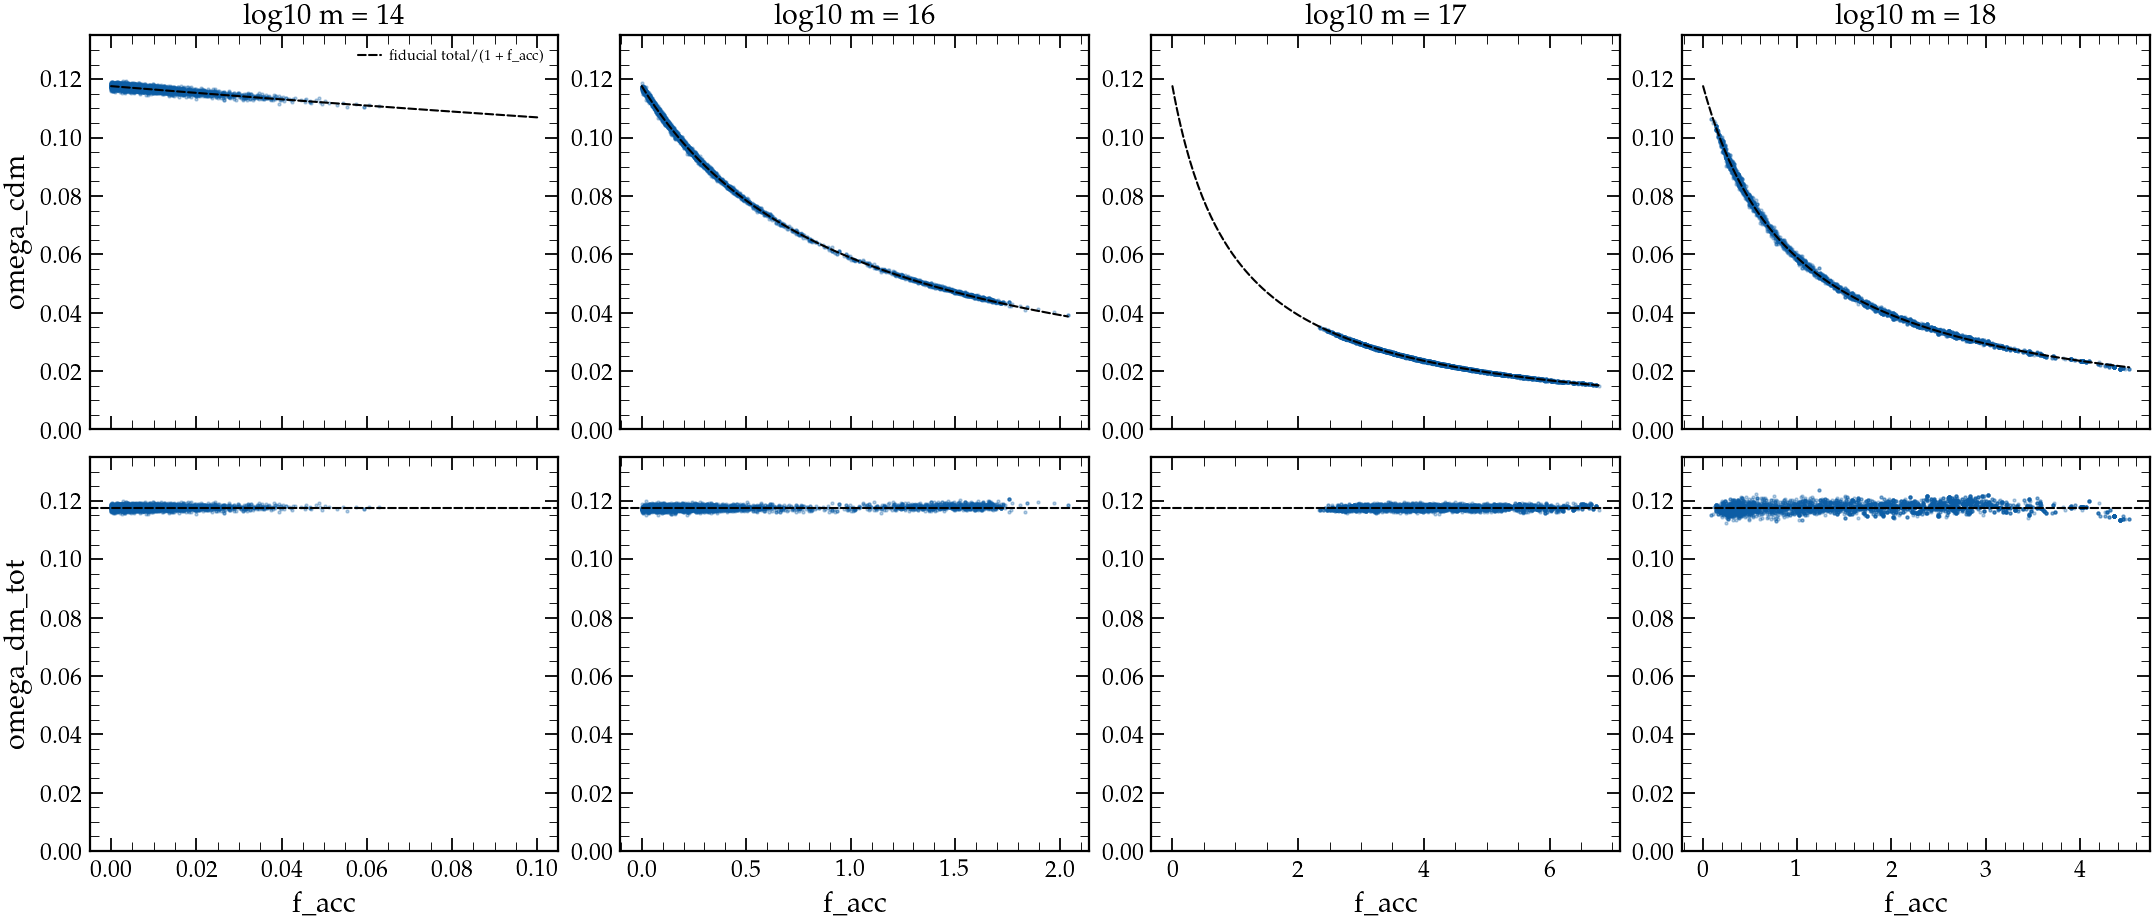

In [5]:
def resample(s, n, seed=0):
    """n weighted draws, for scatter plots."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(s['weight']), size=n, p=s['weight']/s['weight'].sum())
    return {k: v[idx] for k, v in s.items()}


SHOW = [m for m in (14, 16, 17, 18) if m in SAMPLES]
fig, axes = plt.subplots(2, len(SHOW), figsize=(3.6*len(SHOW), 6.2), sharex='col', squeeze=False,
                         constrained_layout=True)
for j, m in enumerate(SHOW):
    r = resample(SAMPLES[m], 4000)
    f = np.linspace(0, max(r['f_acc'].max(), 0.1), 200)
    axes[0, j].scatter(r['f_acc'], r['omega_cdm'], s=2, alpha=0.3)
    axes[0, j].plot(f, OMEGA_DM_TOT/(1 + f), 'k--', lw=1, label='fiducial total/(1 + f_acc)')
    axes[1, j].scatter(r['f_acc'], r['omega_dm_tot'], s=2, alpha=0.3)
    axes[1, j].axhline(OMEGA_DM_TOT, color='k', ls='--', lw=1)
    axes[0, j].set_title('log10 m = {:g}'.format(m))
    axes[1, j].set_xlabel('f_acc')
    for ax in axes[:, j]:
        ax.set_ylim(0, 0.135)
axes[0, 0].set_ylabel('omega_cdm')
axes[1, 0].set_ylabel('omega_dm_tot')
axes[0, 0].legend(fontsize=7)
plt.show()

## 3. Ridge shape and training coverage

With σ the posterior width of ω_dm,tot, the high-likelihood region at fixed f_acc is

- previous: centred on ω_dm,tot/(1 + f_acc), width σ/(1 + f_acc): curved, and 11× narrower at f_acc = 10 than at 0;
- new: centred on ω_dm,tot, width σ: straight and of constant width.

The emulator has to place this region to a fraction of its width at every f_acc, and the likelihood falls
steeply across it, so a narrow, curved ridge is the hardest shape to learn. The first CONNECT iteration is a Latin
hypercube over the training box; below, an 8000-point LHC in the (second coordinate, f_acc) plane counts how many
points fall within ±3σ of the ridge. The other five parameters cut both boxes equally and are left out.

Boxes: previous ω_cdm ∈ [0.01, 0.15] (the fixed-mass CONNECT files); new ω_dm,tot ∈ [0.09, 0.15].

sigma(omega_dm_tot) = 0.0008 (median over chains), ridge half-width 0.0023


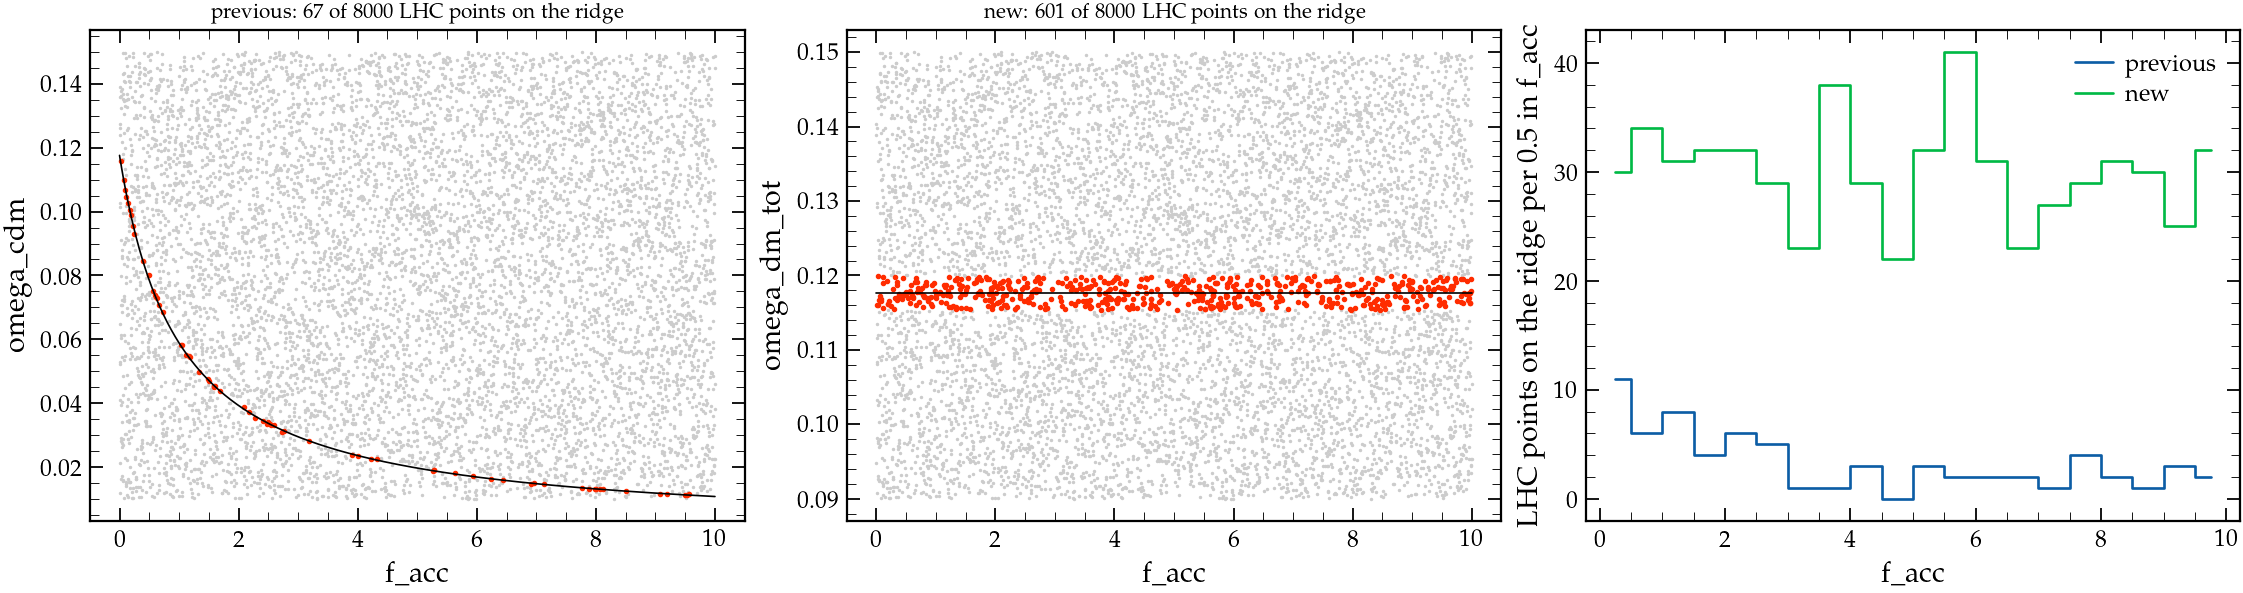

previous  on ridge:   67 total,   17 at f_acc < 1,   50 at f_acc > 1
new       on ridge:  601 total,   64 at f_acc < 1,  537 at f_acc > 1


In [6]:
N_LHC = 8000                                  # N of the first CONNECT iteration
F_BOX = (0.0, 10.0)
BOXES = {'previous': ('omega_cdm', 0.01, 0.15), 'new': ('omega_dm_tot', 0.09, 0.15)}
SIGMA_TOT = float(np.median(table['sd omega_dm_tot']))
HALF_WIDTH = 3*SIGMA_TOT
print('sigma(omega_dm_tot) = {:.4f} (median over chains), ridge half-width {:.4f}'.format(SIGMA_TOT, HALF_WIDTH))

lhc = qmc.LatinHypercube(d=2, seed=1).random(N_LHC)
bins = np.linspace(*F_BOX, 21)
centres = 0.5*(bins[1:] + bins[:-1])
coverage = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, (label, (coord, lo, hi)) in zip(axes, BOXES.items()):
    x = lo + (hi - lo)*lhc[:, 0]
    f = F_BOX[0] + (F_BOX[1] - F_BOX[0])*lhc[:, 1]
    total = x*(1 + f) if coord == 'omega_cdm' else x
    hit = np.abs(total - OMEGA_DM_TOT) < HALF_WIDTH
    coverage[label] = np.histogram(f[hit], bins)[0]
    ff = np.linspace(*F_BOX, 300)
    ridge = OMEGA_DM_TOT/(1 + ff) if coord == 'omega_cdm' else np.full_like(ff, OMEGA_DM_TOT)
    ax.scatter(f[~hit], x[~hit], s=1, color='0.8')
    ax.scatter(f[hit], x[hit], s=4, color='C3')
    ax.plot(ff, ridge, 'k-', lw=0.8)
    ax.set_title('{}: {} of {} LHC points on the ridge'.format(label, hit.sum(), N_LHC), fontsize=10)
    ax.set_xlabel('f_acc')
    ax.set_ylabel(coord)
for label, counts in coverage.items():
    axes[2].step(centres, counts, where='mid', label=label)
axes[2].set_xlabel('f_acc')
axes[2].set_ylabel('LHC points on the ridge per 0.5 in f_acc')
axes[2].legend()
plt.show()

for label, counts in coverage.items():
    print('{:<9s} on ridge: {:4d} total, {:4d} at f_acc < 1, {:4d} at f_acc > 1'.format(
        label, counts.sum(), counts[centres < 1].sum(), counts[centres > 1].sum()))

## 4. The prior

The coordinate change has Jacobian |∂ω_cdm/∂ω_dm,tot| = 1/(1 + f_acc), so

flat in (ω_cdm, f_acc)  ⇔  density ∝ 1/(1 + f_acc) in (ω_dm,tot, f_acc).

The previous parametrization therefore down-weights large f_acc by 1/(1 + f_acc), up to 11× at f_acc = 10, on top
of the likelihood. Sampling ω_dm,tot flat drops that factor. Multiplying the existing chain weights by (1 + f_acc)
previews the flat-ω_dm,tot posterior; this importance reweighting is noisy where the chains are thin, and the
effective-sample ratio says how much is left. It inherits any emulator error in the chains, such as the
f_acc ≈ 1.5 peak at 10¹⁶ GeV (nb35, section 5). To keep the previous prior after switching, weight the new chains
by 1/(1 + f_acc).

Shown for chains where f_acc moves away from 0.

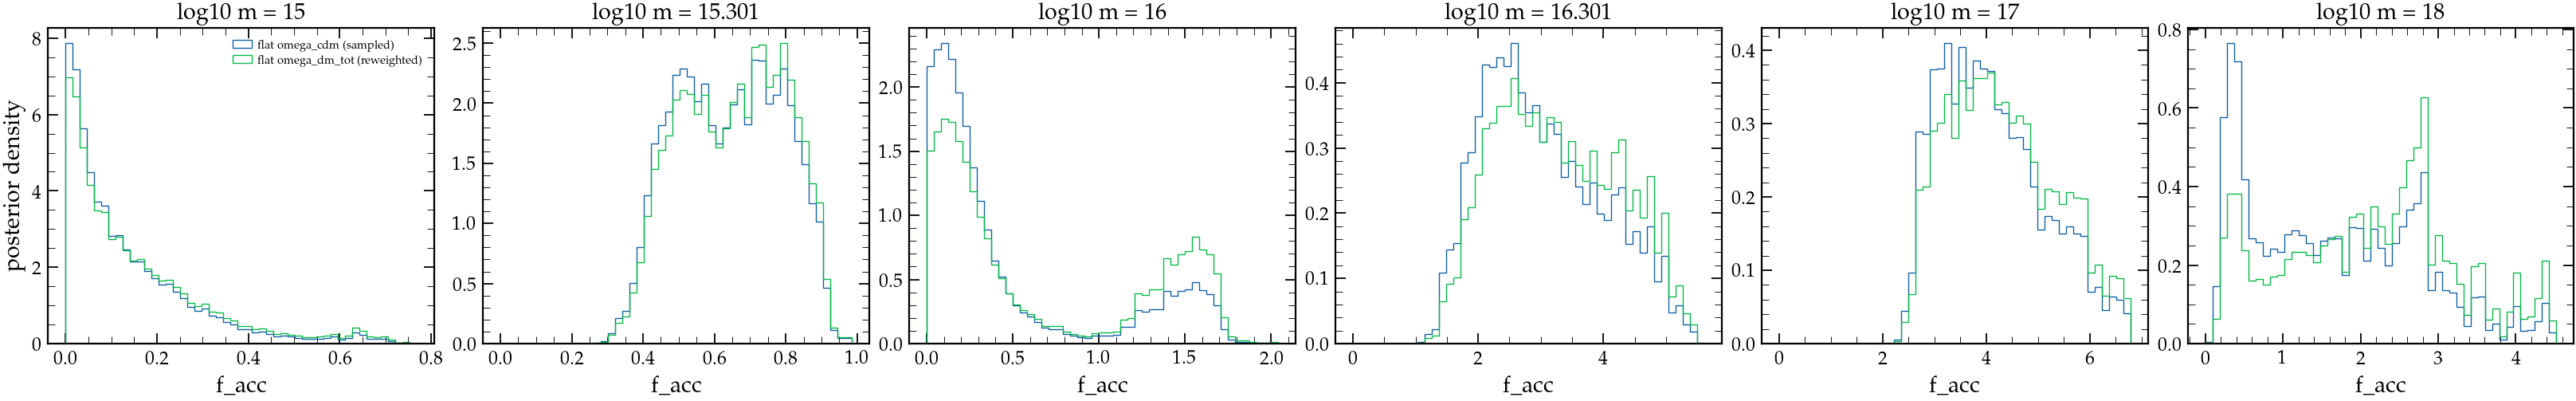

,f95 flat omega_cdm,f95 flat omega_dm_tot,mean f_acc flat omega_cdm,mean f_acc flat omega_dm_tot,ESS ratio
log10m,,,,,
15.000,0.430,0.490,0.138,0.155,1.036
15.301,0.870,0.876,0.640,0.653,0.954
16.000,1.591,1.644,0.471,0.660,0.859
16.301,4.772,4.924,3.040,3.266,0.926
17.000,5.943,6.182,4.114,4.310,0.953
18.000,3.575,4.038,1.655,2.111,0.786


In [7]:
def ess(w):
    return w.sum()**2/np.sum(w**2)


PRIOR_SHOW = [m for m in SAMPLES if table.loc[m, 'mean f_acc'] > 0.05]
rows = []
fig, axes = plt.subplots(1, len(PRIOR_SHOW), figsize=(3.6*len(PRIOR_SHOW), 3.4), squeeze=False,
                         constrained_layout=True)
for ax, m in zip(axes[0], PRIOR_SHOW):
    s = SAMPLES[m]
    w_prev = s['weight']
    w_new = w_prev*(1 + s['f_acc'])
    rows.append({'log10m': m,
                 'f95 flat omega_cdm': wquantile(s['f_acc'], w_prev, 0.95),
                 'f95 flat omega_dm_tot': wquantile(s['f_acc'], w_new, 0.95),
                 'mean f_acc flat omega_cdm': wmean(s['f_acc'], w_prev),
                 'mean f_acc flat omega_dm_tot': wmean(s['f_acc'], w_new),
                 'ESS ratio': ess(w_new)/ess(w_prev)})
    edges = np.linspace(0, s['f_acc'].max(), 50)
    ax.hist(s['f_acc'], edges, weights=w_prev, density=True, histtype='step', label='flat omega_cdm (sampled)')
    ax.hist(s['f_acc'], edges, weights=w_new, density=True, histtype='step', label='flat omega_dm_tot (reweighted)')
    ax.set_title('log10 m = {:g}'.format(m))
    ax.set_xlabel('f_acc')
axes[0, 0].set_ylabel('posterior density')
axes[0, 0].legend(fontsize=7)
plt.show()
display(pd.DataFrame(rows).set_index('log10m').round(3))

## Reading the result

- **Section 1** passing means the patch is a pure change of coordinates: same model, same observables. 1b shows
  ω_dm,tot is today's total cold dark matter (CDM + daughters) to well below the posterior width of ~0.7%.
- **Section 2:** the sd ratio column is how much of the ω_cdm spread is motion along the ridge. Where it is ≫ 1
  (from 10¹⁵ GeV up), the chains are measuring ω_dm,tot and using f_acc to slide along it, and ω_dm,tot has the
  same width as in ΛCDM; the scatter plots show the curved band turning into a straight line.
- **Section 3:** the previous box puts about 10× fewer LHC points on the ridge, and the deficit grows with
  f_acc, as 1/(1 + f_acc): at f_acc > 1, exactly where the high-mass chains end up, it has a few points per unit
  f_acc against about 60 for the new box. Later CONNECT iterations sample from the emulator's own posterior, so a
  region the LHC misses is only learned if an emulator happens to send its MCMC there.
- **Section 4** is the only physical difference. For these chains it raises the 95% f_acc limit by 1–14%, the
  most at 10¹⁵ and 10¹⁸ GeV. Decide which prior the limits are quoted with
  before switching; both are available from either set of chains by reweighting with (1 + f_acc)^±1.

To switch a fixed-mass run (needs the patched CLASS on the cluster too):

- CONNECT: replace `'omega_cdm': [0.01, 0.15]` in `parameters` with `'omega_dm_tot': [0.09, 0.15]`.
- MontePython: replace the ω_cdm line with `data.parameters['omega_dm_tot'] = [0.118, 0.09, 0.15, 0.0013, 1, 'cosmo']`.
- Post-processing: ω_cdm = ω_dm,tot/(1 + f_acc).